# Coursework 2

In this coursework, you will work with a multimodal bird species classification dataset containing both images and textual descriptions (captions). The dataset has 200 classes and around 10 000 data points. Rather than training deep neural networks from scratch, you will use pre-extracted features generated by a large pre-trained vision–language model (called SigLIP). These features provide numerical representations of the images and captions, allowing you to focus on machine learning methods such as classification, clustering, and similarity analysis.

Each sample in the original dataset consists of:
- An image of a bird
- A natural language caption describing the bird
- A class label for the bird species

The dataset has already been split into training and test sets. The test labels are withheld for marking.

You are provided with the following files:

**Feature embeddings (from SigLIP):**
- `image_features_train.npy`
- `image_features_test.npy`
- `caption_features_train.npy`
- `caption_features_test.npy`

These contain numerical feature vectors extracted from the images and captions.

**Raw data (for inspection only):**
- `images_train.npy` — the original images  
- `captions_train.npy` — the original text captions  

You may use these files to better understand the dataset, but all modelling should be performed using the provided features.

**Labels:**
- `labels_train.npy` — training labels  
- `labels_test.npy` — not provided (withheld for evaluation)

## Coursework Submission

Your submission will consist of the following two files:

1. **`cwk2.ipynb`** — your completed notebook, with all cells run and outputs visible.
2. **`test_predictions.csv`** — your model's predictions for the test set (Task 4).

Put these two files in a .zip file named according to your student id, e.g. 12314567g.zip. Upload the zip file for grading via "Coursework 2 submission" on Moodle.

Make sure your notebook runs from top to bottom without errors on a clean machine before submitting, without dependencies on packages other than `numpy`, `pandas`, `scipy`, `sklearn` or standard Python-included packages. The other coursework files (images, captions, features, labels etc.) should not be submitted, but you should assume they are located in the same folder as your submission notebook when you load them in.

Image:


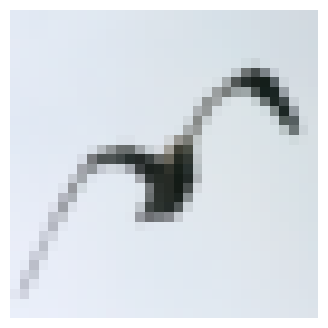

Caption:
the bird has beak and head proportional to its body with its whole body covered in black.


In [9]:
# let's inspect the images and captions
import numpy as np
import matplotlib.pyplot as plt

images = np.load("images_train.npy")
captions = np.load("captions_train.npy", allow_pickle=True)

idx = 0  # change index to inspect different samples

print("Image:")
plt.figure(figsize=(4, 4))
plt.imshow(images[idx])
plt.axis("off")
plt.show()

print("Caption:")
print(captions[idx])

## Task 1: Image Feature Analysis (5 marks)

In this task, you will work with the pre-extracted features from the images, along with the class labels:
- `image_features_train.npy` (features of the images from the training set)
- `labels_train.npy` (corresponding class labels)

Your task is to quantify how well the features separate different classes using Euclidean distance.

You must compute:

- **Intra-class distance:** the average Euclidean distance between all pairs of samples that share the same class label. Do not pair a sample with itself.
- **Inter-class distance:** the average Euclidean distance between all pairs of samples that have different class labels.

Then compute the separation ratio:

$$
\text{Separation Ratio} = \frac{\text{Inter-class distance}}{\text{Intra-class distance}}
$$

You can use the provided `distance` function to compute the Euclidean distance between any two features, but you don't have to.

Submission requirements:
- Your code should print a single numeric value: the separation ratio.
- Include the full code used to compute it.
- Do not remove the `%%time` magic command from the top of the cell — this is used to measure the runtime of your solution.

Marking:
- 3 marks for the correct separation ratio.
- 2 marks for an efficient solution that runs in under 60 seconds.

In [ ]:
%%time
import numpy as np

def distance(a, b):
    """
    Computes and returns the Euclidean distance between two features a and b.
    """
    return np.sqrt(np.sum((a-b)**2))

# Load data
image_features_train = np.load("image_features_train.npy")
labels_train = np.load("labels_train.npy")

# YOUR CODE HERE

print(f"Separation ratio: {separation_ratio:.4f}")

## Task 2: Retrieval Across Images and Captions (5 marks)

In this task, you will use both the image and caption features.

You are provided:
- `image_features_train.npy`
- `caption_features_train.npy`

Your goal is to measure how well images and captions align in their feature spaces.

You must:

- Compute the Euclidean distance between every image feature and every caption feature.
- For each image, identify the 5 closest caption features.
- Check whether the correct caption for that image appears among those 5 closest captions. The correct caption for image $i$ is caption $i$.
- Compute the proportion of images for which this is true.

You can use the `distance` function provided in Task 1 to compute the Euclidean distance between any two features.

Submission requirements:
- Your code should print a single numeric value: the proportion of images whose correct caption is among the 5 closest captions.
- Include the full code used to compute it.
- Do not remove the `%%time` magic command from the top of the cell — this is used to measure the runtime of your solution.

Marking:
- 3 marks for the correct proportion.
- 2 marks for an efficient solution that runs in under 60 seconds.

In [ ]:
%%time

import numpy as np

# Load both sets of features
image_features_train = np.load("image_features_train.npy")
caption_features_train = np.load("caption_features_train.npy")

# YOUR CODE HERE

print("Proportion with correct caption in top 5:", proportion)

## Task 3: Clustering (5 marks)

In this task, you will cluster both image features and caption features, and interpret what the clusters capture.

You are provided:
- `image_features_train.npy`
- `caption_features_train.npy`
- `images_train.npy` (for your own inspection)
- `captions_train.npy` (for your own inspection)

You must fit KMeans with 200 clusters and `random_state=42` separately to the image features and the caption features.

**Part A: Image cluster interpretation (2 marks)**
Find the two image clusters whose centroids are furthest apart. Inspect the images in those clusters, then describe in 1-2 sentences the most obvious visual differences between them.

**Part B: Caption cluster interpretation (2 marks)**
Find the two caption clusters whose centroids are furthest apart. Inspect the captions in those clusters, then describe in 1-2 sentences the most obvious differences in the language used.

**Part C: Clustering agreement (1 mark)**
Compute the **Adjusted Rand Index (ARI)** between the image cluster assignments and the caption cluster assignments using `sklearn.metrics.adjusted_rand_score`.

Submission requirements:
- Write your answers to Parts A and B as strings in the code cell where indicated.
- Part C should print a single numeric value: the ARI score.

Marking:
- 2 marks for a correct and well-reasoned interpretation of the image clusters.
- 2 marks for a correct and well-reasoned interpretation of the caption clusters.
- 1 mark for the correct ARI score.

In [ ]:
import numpy as np
from sklearn.metrics import adjusted_rand_score

# Load features
image_features_train = np.load("image_features_train.npy")
caption_features_train = np.load("caption_features_train.npy")

# YOUR CODE HERE


# Answer part A: describe the most obvious visual differences between the two most distant image clusters
# REPLACE THIS COMMENT WITH YOUR ANSWER

# Answer part B: describe the most obvious differences in language between the two most distant caption clusters
# REPLACE THIS COMMENT WITH YOUR ANSWER

# Part C: print the ARI score between image and caption cluster assignments
print(f"Adjusted Rand Index: {ari_score:.4f}")

## Task 4: Classification (10 marks)

In this task, your goal is to train a classifier using the training features, tune its hyperparameters to achieve the best possible performance, and generate predictions for the test set. You must submit your predictions as a CSV file containing a single column of label indices (one row per test sample, in order).

You should use one of the following supervised models:
- Logistic Regression  
- k-Nearest Neighbors  
- Decision Tree  
- Multi-Layer Perceptron (MLP)  

You can use either the image features, the caption features, or a combination of the two. But you should only train one model.

Your marks will depend on the F1 score achieved on the hidden test set, with higher performance receiving more credit.

Submission requirements:
- Use `image_features_test.npy` and/or `caption_features_test.npy` to generate model predictions.
- Save the model predictions in a file called `test_predictions.csv`.

In [ ]:
import numpy as np
import pandas as pd

# Load features and labels
image_features_train = np.load("image_features_train.npy")
caption_features_train = np.load("caption_features_train.npy")
labels_train = np.load("labels_train.npy")

image_features_test = np.load("image_features_test.npy")
caption_features_test = np.load("caption_features_test.npy")

# YOUR CODE HERE

# Use the below code to save your model's test set predictions in a standardised format
df_predictions = pd.DataFrame({
    "label": np.asarray(predictions).reshape(-1)
})
df_predictions.to_csv("test_predictions.csv", index=False)